### This notebook analysis data from the CTD in the CAPSTAN voyage

In [173]:
# Import packages
import os              # For file path handling
import time            # For sleep during retry logic
import shutil          # For copying downloaded content
import requests        # For HTTP downloads
import urllib3         # For disabling SSL warnings
import numpy as np     # For logical operations and array handling
import pandas as pd    # For reading and manipulating the GDAC index
from datetime import datetime  # For date filtering
import xarray as xr 
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cmocean
import gsw as gsw

In [175]:
os.chdir(r'C:\Users\nribeiro\OneDrive - University of Tasmania\IMOS Shared Docs\CAPSTAN 2025\Datasets\CTD KI') #Will need to change this 

In [176]:
ds = xr.open_mfdataset(
    "in2026_*.nc",
    combine="by_coords"
)


In [177]:
ds

<xarray.Dataset>
Dimensions:              (time: 6, latitude: 6, pressure: 5183, longitude: 6)
Coordinates:
  * time                 (time) datetime64[ns] 2026-04-29T05:00:37.252003840 ...
  * latitude             (latitude) float64 -36.48 -36.44 ... -36.38 -36.37
  * pressure             (pressure) float64 3.0 4.0 ... 5.181e+03 5.182e+03
  * longitude            (longitude) float64 134.1 136.0 136.0 136.0 136.0 136.0
Data variables: (12/30)
    woce_date            (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    woce_time            (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    temperature          (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    temperatureFlag      (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    conductivity         (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    conductivityFlag     (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    ...                   ...
    transmissometer      (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    transmissometerFlag  (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    fluorometer          (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    fluorometerFlag      (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    obs                  (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    obsFlag              (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
Attributes: (12/14)
    WOCE_Version:    3.0
    Conventions:     COARDS/WOCE/CF-1.5
    History:         Created on 30-Apr-2026 07:50:40
    Organisation:    CSIRO Marine Research
    Survey:          IN2026_T02
    Vessel:          RV Investigator
    ...              ...
    StartTime:       29-Apr-2026 05:00:37
    BottomTime:      29-Apr-2026 06:38:46
    EndTime:         29-Apr-2026 08:15:30
    WaterDepth:      5098.8501
    MinAltitude:     Unknown
    PressureBin:     1

In [178]:
#gsw_SA_CT_plot(SA,)

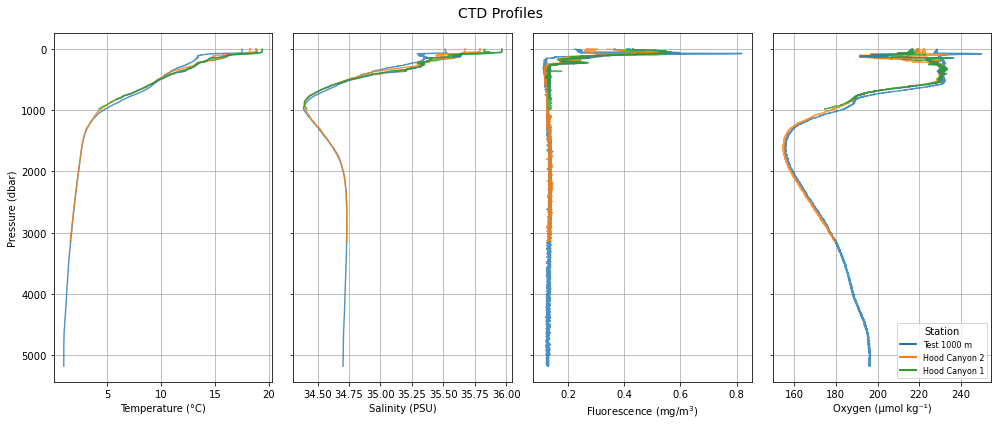

In [179]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

vars_to_plot = {
    "Temperature (°C)": "temperature",
    "Salinity (PSU)": "salinity",
    "Fluorescence (mg/m$^{3}$)": "fluorometer",
    "Oxygen (µmol kg⁻¹)": "oxygen",
}

pressure = ds["pressure"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(14, 6),
    sharey=True
)

# Define a consistent colour per "station"
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

station_labels = [
    "Test 1000 m",
    "Hood Canyon 2",
    "Hood Canyon 1"
]

# Number of distinct stations you want to show
n_stations = len(station_labels)

for ax, (xlabel, varname) in zip(axes, vars_to_plot.items()):
    var = ds[varname]

    station_counter = 0

    for t in range(ds.dims["time"]):
        for la in range(ds.dims["latitude"]):
            for lo in range(ds.dims["longitude"]):

                # Cycle colours if more profiles than stations
                color = colors[station_counter % n_stations]

                profile = var.isel(
                    time=t,
                    latitude=la,
                    longitude=lo
                )

                ax.plot(
                    profile,
                    pressure,
                    color=color,
                    lw=1.4,
                    alpha=0.8
                )

                station_counter += 1

    ax.set_xlabel(xlabel)
    ax.grid(True)

axes[0].set_ylabel("Pressure (dbar)")
axes[0].invert_yaxis()

# manual legend with matching colours
legend_handles = [
    Line2D(
        [0], [0],
        color=colors[i],
        lw=2,
        label=station_labels[i]
    )
    for i in range(n_stations)
]

# Legend in the last panel
axes[-1].legend(
    handles=legend_handles,
    loc="best",
    fontsize=8,
    title="Station"
)

fig.suptitle("CTD Profiles", fontsize=14)
plt.tight_layout()
plt.show()

### TS Diagram 

C:\Users\nribeiro\AppData\Local\Temp\ipykernel_11360\1755178033.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 1])


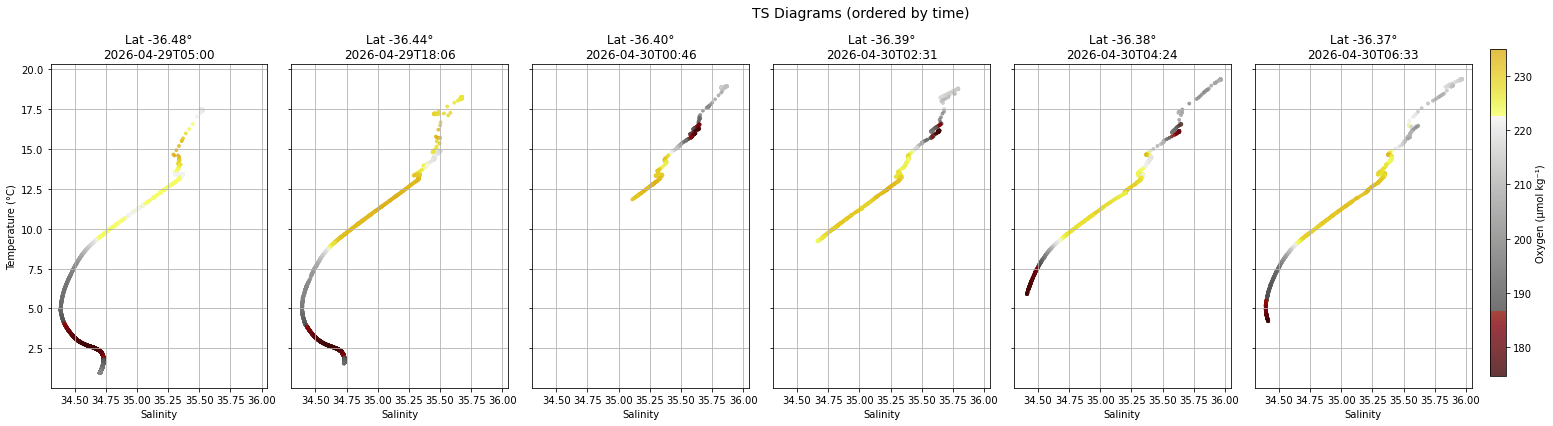

In [180]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

# Variable names
temp_var = "temperature"
oxy_var  = "oxygen"
sal_var  = "salinity"

times = ds.time.values
latitudes = ds.latitude.values
n_stations = len(times)

# Stations already ordered by time
time_order = np.argsort(times)

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_stations,
    figsize=(4 * n_stations, 6),
    sharex=True,
    sharey=True
)

if n_stations == 1:
    axes = [axes]

# LOOP OVER TIME
for ax, ti in zip(axes, time_order):

    T = ds[temp_var].isel(time=ti).values.flatten()
    S = ds[sal_var].isel(time=ti).values.flatten()
    O2 = ds[oxy_var].isel(time=ti).values.flatten()

    sc = ax.scatter(
        S,
        T,
        c=O2,
        cmap=cmocean.cm.oxy,
        s=8,
        alpha=0.8
    )

    time_str = np.datetime_as_string(times[ti], unit="m")
    lat = latitudes[ti]

    ax.set_title(f"Lat {lat:.2f}°\n{time_str}")
    ax.set_xlabel("Salinity")
    ax.grid(True)

axes[0].set_ylabel("Temperature (°C)")

# Shared colourbar
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation="vertical",
    fraction=0.046,
    pad=0.04
)
cbar.set_label("Oxygen (µmol kg⁻¹)")

fig.suptitle("TS Diagrams (ordered by time)", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()


### TS Plot identifying water masses

C:\Users\nribeiro\AppData\Local\Temp\ipykernel_11360\681062342.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 1])


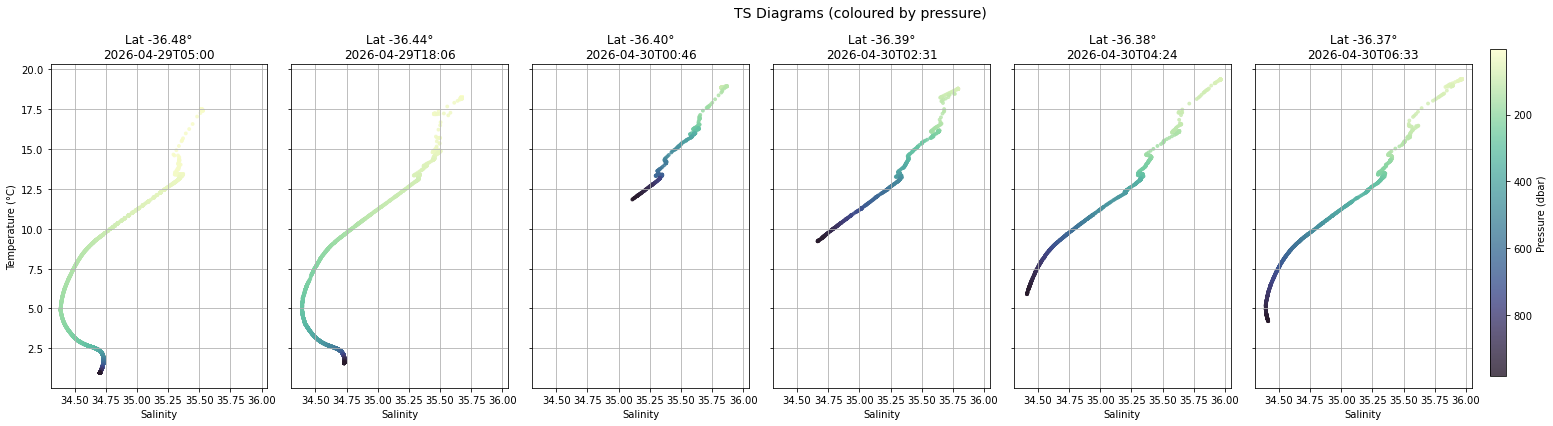

In [181]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

temp_var = "temperature"
sal_var  = "salinity"

times = ds.time.values
latitudes = ds.latitude.values
n_stations = len(times)

# Stations already ordered by time
time_order = np.argsort(times)

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_stations,
    figsize=(4 * n_stations, 6),
    sharex=True,
    sharey=True
)

if n_stations == 1:
    axes = [axes]

for ax, ti in zip(axes, time_order):

    # TS data
    T = ds[temp_var].isel(time=ti).values.flatten()
    S = ds[sal_var].isel(time=ti).values.flatten()

    # Pressure values for each TS point
    P = np.tile(
        ds.pressure.values,
        int(T.size / ds.pressure.size)
    )

    sc = ax.scatter(
        S,
        T,
        c=P,
        cmap=cmocean.cm.deep,   # good pressure colormap
        s=8,
        alpha=0.8
    )

    time_str = np.datetime_as_string(times[ti], unit="m")
    lat = latitudes[ti]

    ax.set_title(f"Lat {lat:.2f}°\n{time_str}")
    ax.set_xlabel("Salinity")
    ax.grid(True)

axes[0].set_ylabel("Temperature (°C)")

# Shared pressure colourbar
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation="vertical",
    fraction=0.046,
    pad=0.04
)

cbar.set_label("Pressure (dbar)")
cbar.ax.invert_yaxis()   # deep water = darker colours

fig.suptitle(
    "TS Diagrams (coloured by pressure)",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()

In [182]:
os.chdir(r'C:\Users\nribeiro\OneDrive - University of Tasmania\IMOS Shared Docs\CAPSTAN 2025\Datasets\CTD KI') #Will need to change this 

In [183]:
ds = xr.open_mfdataset(
    "in2026_*.nc",
    combine="by_coords"
)

In [184]:
ds

<xarray.Dataset>
Dimensions:              (time: 6, latitude: 6, pressure: 5183, longitude: 6)
Coordinates:
  * time                 (time) datetime64[ns] 2026-04-29T05:00:37.252003840 ...
  * latitude             (latitude) float64 -36.48 -36.44 ... -36.38 -36.37
  * pressure             (pressure) float64 3.0 4.0 ... 5.181e+03 5.182e+03
  * longitude            (longitude) float64 134.1 136.0 136.0 136.0 136.0 136.0
Data variables: (12/30)
    woce_date            (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    woce_time            (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    temperature          (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    temperatureFlag      (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    conductivity         (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    conductivityFlag     (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    ...                   ...
    transmissometer      (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    transmissometerFlag  (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    fluorometer          (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    fluorometerFlag      (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    obs                  (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
    obsFlag              (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 6, 5183, 6), meta=np.ndarray>
Attributes: (12/14)
    WOCE_Version:    3.0
    Conventions:     COARDS/WOCE/CF-1.5
    History:         Created on 30-Apr-2026 07:50:40
    Organisation:    CSIRO Marine Research
    Survey:          IN2026_T02
    Vessel:          RV Investigator
    ...              ...
    StartTime:       29-Apr-2026 05:00:37
    BottomTime:      29-Apr-2026 06:38:46
    EndTime:         29-Apr-2026 08:15:30
    WaterDepth:      5098.8501
    MinAltitude:     Unknown
    PressureBin:     1

In [185]:
## Calculate density

In [186]:
# Extract coordinate arrays
lon0 = ds.longitude.values
lat0 = ds.latitude.values

# Broadcast to full 4D shape of temperature
lon = np.broadcast_to(lon0, ds.temperature.shape)
lat = np.broadcast_to(lat0, ds.temperature.shape)


In [187]:
T  = ds.temperature.values.flatten()
S  = ds.salinity.values.flatten()
O2 = ds.oxygen.values.flatten()

P = np.tile(
    ds.pressure.values,
    int(T.size / ds.pressure.size)
)

lon = lon.flatten()
lat = lat.flatten()

In [188]:
mask = np.isfinite(T) & np.isfinite(S) & np.isfinite(O2) & np.isfinite(P)

T  = T[mask]
S  = S[mask]
O2 = O2[mask]
P  = P[mask]
lon = lon[mask]
lat = lat[mask]


In [189]:
SA = gsw.SA_from_SP(S, P, lon, lat)
CT = gsw.CT_from_t(SA, T, P)
sigma0 = gsw.sigma0(SA, CT)

In [190]:
## KI Transect

In [191]:
ds_sec = ds.mean(dim=["longitude", "time"])

In [192]:
ds_sec

<xarray.Dataset>
Dimensions:              (latitude: 6, pressure: 5183)
Coordinates:
  * latitude             (latitude) float64 -36.48 -36.44 ... -36.38 -36.37
  * pressure             (pressure) float64 3.0 4.0 ... 5.181e+03 5.182e+03
Data variables: (12/30)
    woce_date            (latitude, pressure) float64 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    woce_time            (latitude, pressure) float64 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    temperature          (latitude, pressure) float64 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    temperatureFlag      (latitude, pressure) float32 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    conductivity         (latitude, pressure) float64 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    conductivityFlag     (latitude, pressure) float32 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    ...                   ...
    transmissometer      (latitude, pressure) float64 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    transmissometerFlag  (latitude, pressure) float32 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    fluorometer          (latitude, pressure) float64 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    fluorometerFlag      (latitude, pressure) float32 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    obs                  (latitude, pressure) float64 dask.array<chunksize=(6, 5183), meta=np.ndarray>
    obsFlag              (latitude, pressure) float32 dask.array<chunksize=(6, 5183), meta=np.ndarray>

In [193]:
Tsec = ds_sec.temperature.compute()
P = ds_sec.pressure
lat = ds_sec.latitude

Ssec = ds_sec.salinity.compute()

In [194]:
Osec = ds_sec.oxygen.compute()

In [195]:
## masking depths

In [196]:
# Tsec dims: (pressure, latitude)
max_p = Tsec.notnull().where(Tsec.notnull()).idxmax(dim="pressure")



In [197]:
Tsec_masked = Tsec.where(Tsec.pressure <= max_p)

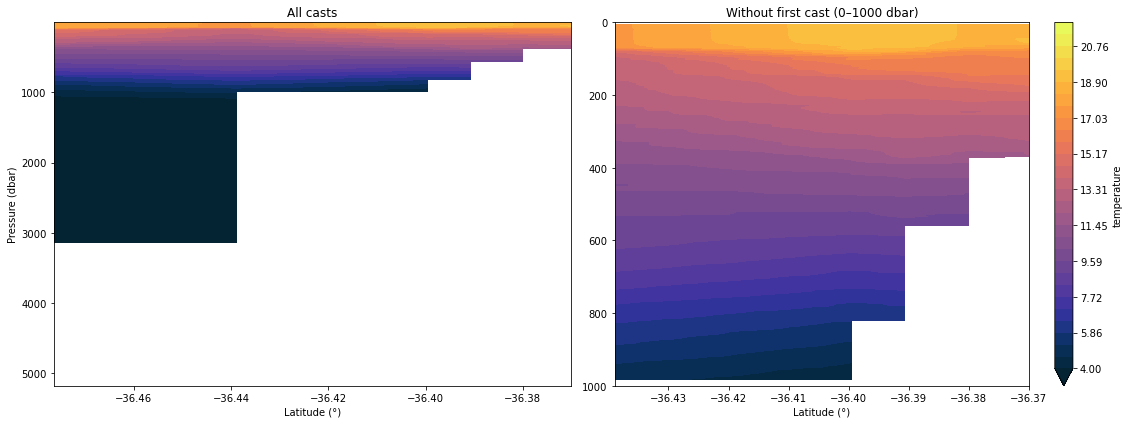

In [198]:
vmin = 4
vmax = 22


fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharey=False   # important: do NOT share y-axis
)

# --- Panel 1: All casts ---
Tsec.plot.contourf(
    ax=axes[0],
    x="latitude",
    y="pressure",
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap=cmocean.cm.thermal,
    add_colorbar=False
)

axes[0].invert_yaxis()
axes[0].set_title("All casts")
axes[0].set_xlabel("Latitude (°)")
axes[0].set_ylabel("Pressure (dbar)")

# --- Panel 2: Without first cast, 0–1000 dbar ---
Tsec.isel(latitude=slice(1, None)).plot.contourf(
    ax=axes[1],
    x="latitude",
    y="pressure",
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap=cmocean.cm.thermal,
    add_colorbar=True
)

axes[1].invert_yaxis()
axes[1].set_ylim(1000, 0)   # <-- key line
axes[1].set_title("Without first cast (0–1000 dbar)")
axes[1].set_xlabel("Latitude (°)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


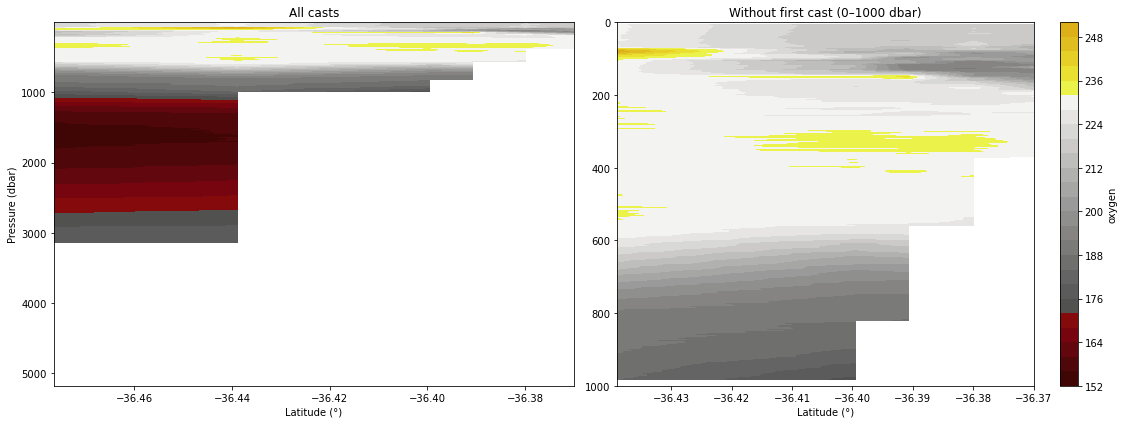

In [199]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharey=False   # important: do NOT share y-axis
)

# --- Panel 1: All casts ---
Osec.plot.contourf(
    ax=axes[0],
    x="latitude",
    y="pressure",
    levels=30,
    cmap=cmocean.cm.oxy,
    add_colorbar=False
)

axes[0].invert_yaxis()
axes[0].set_title("All casts")
axes[0].set_xlabel("Latitude (°)")
axes[0].set_ylabel("Pressure (dbar)")

# --- Panel 2: Without first cast, 0–1000 dbar ---
Osec.isel(latitude=slice(1, None)).plot.contourf(
    ax=axes[1],
    x="latitude",
    y="pressure",
    levels=30,
    cmap=cmocean.cm.oxy,
    add_colorbar=True
)

axes[1].invert_yaxis()
axes[1].set_ylim(1000, 0)   # <-- key line
axes[1].set_title("Without first cast (0–1000 dbar)")
axes[1].set_xlabel("Latitude (°)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()



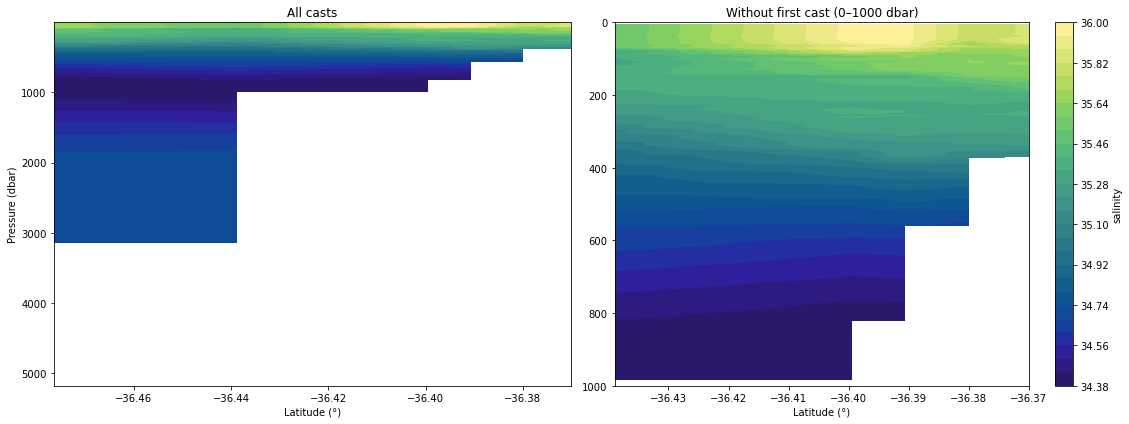

In [200]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharey=False   # important: do NOT share y-axis
)

# --- Panel 1: All casts ---
Ssec.plot.contourf(
    ax=axes[0],
    x="latitude",
    y="pressure",
    levels=30,
    cmap=cmocean.cm.haline,
    add_colorbar=False
)

axes[0].invert_yaxis()
axes[0].set_title("All casts")
axes[0].set_xlabel("Latitude (°)")
axes[0].set_ylabel("Pressure (dbar)")

# --- Panel 2: Without first cast, 0–1000 dbar ---
Ssec.isel(latitude=slice(1, None)).plot.contourf(
    ax=axes[1],
    x="latitude",
    y="pressure",
    levels=30,
    cmap=cmocean.cm.haline,
    add_colorbar=True
)

axes[1].invert_yaxis()
axes[1].set_ylim(1000, 0)   # <-- key line
axes[1].set_title("Without first cast (0–1000 dbar)")
axes[1].set_xlabel("Latitude (°)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()



In [201]:
## TS plots

In [202]:
# Calculate indexes for water masses

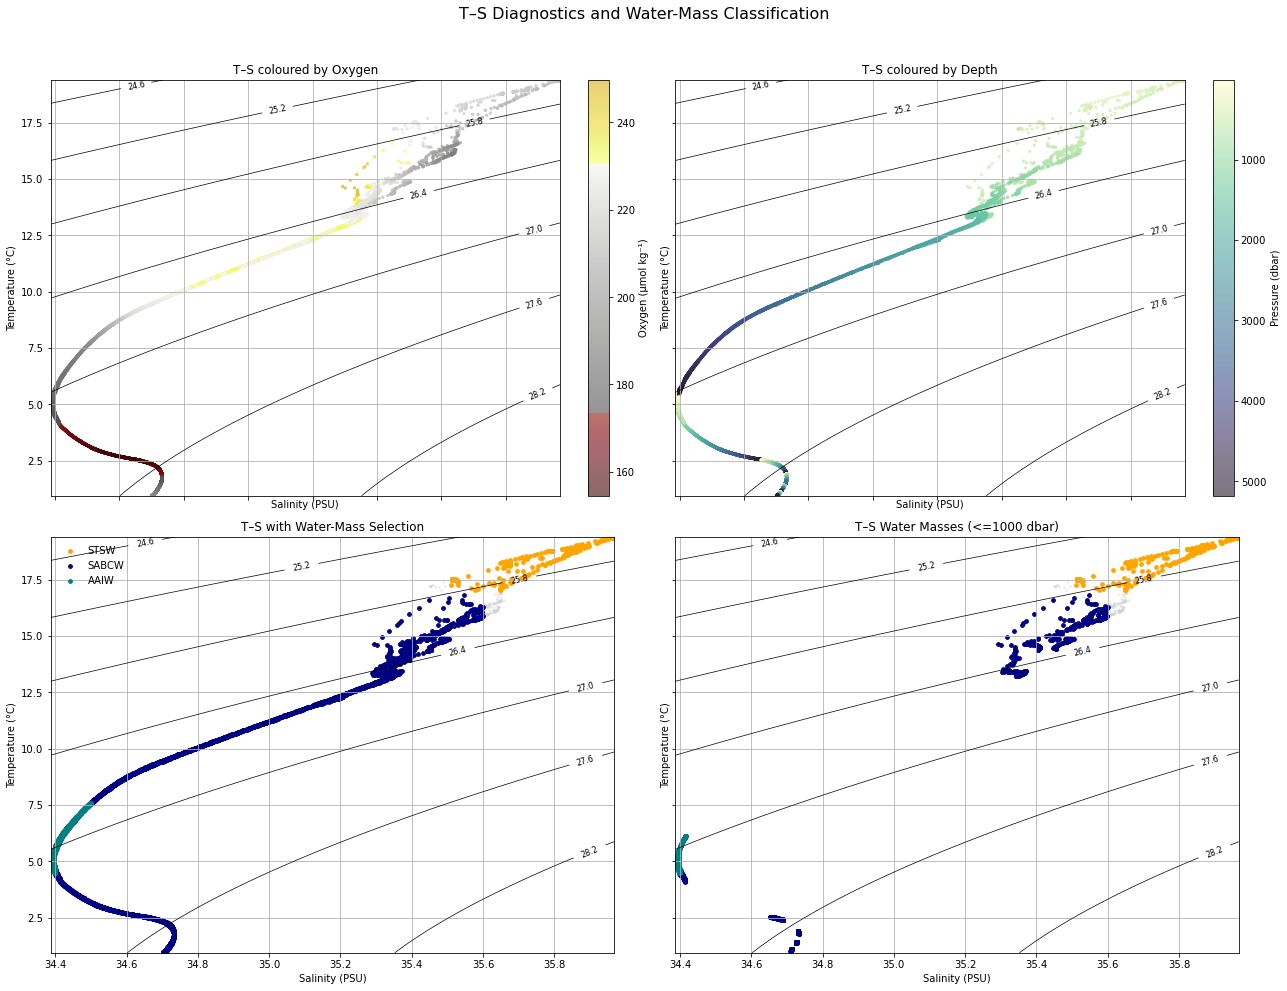

In [203]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean
import gsw

# --------------------------------------------------
# Variables
# --------------------------------------------------
temp_var = "temperature"
sal_var  = "salinity"
oxy_var  = "oxygen"

pressure = ds.pressure.values

# --------------------------------------------------
# Build ONE global flattened dataset (CRITICAL FIX)
# --------------------------------------------------
T = ds[temp_var].values.flatten()
S = ds[sal_var].values.flatten()
O2 = ds[oxy_var].values.flatten()

P = np.tile(
    pressure,
    int(T.size / pressure.size)
)

mask = np.isfinite(T) & np.isfinite(S) & np.isfinite(O2) & np.isfinite(P)

T  = T[mask]
S  = S[mask]
O2 = O2[mask]
P  = P[mask]

# --------------------------------------------------
# Water-mass indices (NOW CORRECT)
# --------------------------------------------------
idx_STSW  = (T > 17) & (S > 35.5)
idx_SABCW = (T < 17) & (S < 35.6)
idx_NWIIW = (O2 < 110) & (P > 600)
idx_AAIW  = (S < 34.5) & (S > 34.1) & (T > 2) & (T < 8) & (O2 > 180)
idx_NADW = (S > 34.9) & (T > 2) & (T < 4)

deep = P <= 1000

# --------------------------------------------------
# Create 2×2 figure
# --------------------------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 14),
    sharex=True,
    sharey=True
)

ax_oxy, ax_depth = axes[0]
ax_wm, ax_wm_deep = axes[1]

# --------------------------------------------------
# Panel 1: T–S coloured by oxygen
# --------------------------------------------------
sc_oxy = ax_oxy.scatter(
    S, T, c=O2,
    cmap=cmocean.cm.oxy,
    s=6, alpha=0.6
)

# --------------------------------------------------
# Panel 2: T–S coloured by depth
# --------------------------------------------------
sc_dep = ax_depth.scatter(
    S, T, c=P,
    cmap=cmocean.cm.deep,
    s=6, alpha=0.6
)

# --------------------------------------------------
# Panel 3: Water-mass classification (ALL data)
# --------------------------------------------------
ax_wm.scatter(S, T, s=3, color="lightgrey", alpha=0.3)

ax_wm.scatter(S[idx_STSW],  T[idx_STSW],  color="orange",     s=14, label="STSW")
ax_wm.scatter(S[idx_SABCW], T[idx_SABCW], color="navy",       s=14, label="SABCW")
#ax_wm.scatter(S[idx_NWIIW], T[idx_NWIIW], color="red",  s=14, label="NWIIW")
ax_wm.scatter(S[idx_AAIW],  T[idx_AAIW],  color="teal",       s=14, label="AAIW")
#ax_wm.scatter(S[idx_NADW],  T[idx_NADW],  color="red",       s=14, label="NADW")

# --------------------------------------------------
# Panel 4: Deep water only (<=1000 dbar)
# --------------------------------------------------
ax_wm_deep.scatter(
    S[deep], T[deep],
    s=3, color="lightgrey", alpha=0.3
)

ax_wm_deep.scatter(
    S[idx_SABCW & deep], T[idx_SABCW & deep],
    color="navy", s=14
)
ax_wm_deep.scatter(
    S[idx_STSW & deep], T[idx_STSW & deep],
    color="orange", s=14
)

ax_wm_deep.scatter(
    S[idx_AAIW & deep], T[idx_AAIW & deep],
    color="teal", s=14
)



# --------------------------------------------------
# Isopycnals (σ₀)
# --------------------------------------------------
Sg, Tg = np.meshgrid(
    np.linspace(S.min(), S.max(), 120),
    np.linspace(T.min(), T.max(), 120)
)

sigma0 = gsw.sigma0(Sg, Tg)

for ax in [ax_oxy, ax_depth, ax_wm, ax_wm_deep]:
    cs = ax.contour(Sg, Tg, sigma0, colors="k", linewidths=0.7)
    ax.clabel(cs, fmt="%.1f", fontsize=8)
    ax.grid(True)

# --------------------------------------------------
# Labels & titles
# --------------------------------------------------
ax_oxy.set_title("T–S coloured by Oxygen")
ax_depth.set_title("T–S coloured by Depth")
ax_wm.set_title("T–S with Water-Mass Selection")
ax_wm_deep.set_title("T–S Water Masses (<=1000 dbar)")

for ax in axes.ravel():
    ax.set_xlabel("Salinity (PSU)")
    ax.set_ylabel("Temperature (°C)")

# --------------------------------------------------
# Colourbars
# --------------------------------------------------
cbar_oxy = fig.colorbar(sc_oxy, ax=ax_oxy, fraction=0.046)
cbar_oxy.set_label("Oxygen (µmol kg⁻¹)")

cbar_dep = fig.colorbar(sc_dep, ax=ax_depth, fraction=0.046)
cbar_dep.set_label("Pressure (dbar)")
cbar_dep.ax.invert_yaxis()

ax_wm.legend(frameon=False)

fig.suptitle("T–S Diagnostics and Water-Mass Classification", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

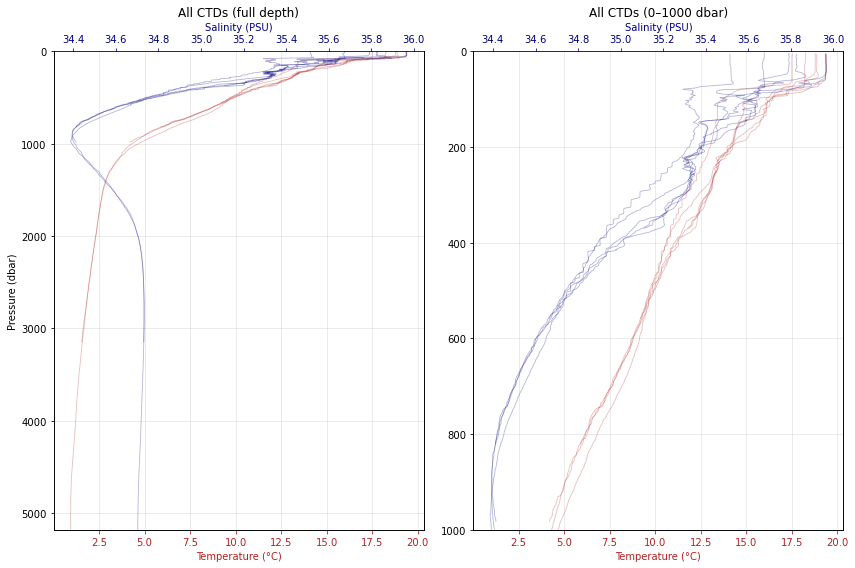

In [55]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 8),
    sharey=False
)

pressure = ds.pressure

# Create twin x-axes
axT_full = axes[0]
axS_full = axT_full.twiny()

axT_shallow = axes[1]
axS_shallow = axT_shallow.twiny()

# Loop over all CTDs
for t in range(ds.sizes["time"]):
    for la in range(ds.sizes["latitude"]):
        for lo in range(ds.sizes["longitude"]):

            T = ds.temperature.isel(
                time=t, latitude=la, longitude=lo
            )
            S = ds.salinity.isel(
                time=t, latitude=la, longitude=lo
            )

            # --- Full depth panel ---
            axT_full.plot(
                T, pressure,
                color="firebrick", lw=0.8, alpha=0.3
            )
            axS_full.plot(
                S, pressure,
                color="navy", lw=0.8, alpha=0.3
            )

            # --- 0–1000 dbar panel ---
            axT_shallow.plot(
                T, pressure,
                color="firebrick", lw=0.8, alpha=0.3
            )
            axS_shallow.plot(
                S, pressure,
                color="navy", lw=0.8, alpha=0.3
            )

# Invert pressure axis
for ax in [axT_full, axT_shallow]:
    ax.invert_yaxis()

# Set y-limits
axT_full.set_ylim(pressure.max(), 0)
axT_shallow.set_ylim(1000, 0)

# Labels
axT_full.set_xlabel("Temperature (°C)", color="firebrick")
axS_full.set_xlabel("Salinity (PSU)", color="navy")
axT_shallow.set_xlabel("Temperature (°C)", color="firebrick")
axS_shallow.set_xlabel("Salinity (PSU)", color="navy")

axT_full.set_ylabel("Pressure (dbar)")

# Titles
axT_full.set_title("All CTDs (full depth)")
axT_shallow.set_title("All CTDs (0–1000 dbar)")

# Tick colours for clarity
axT_full.tick_params(axis="x", colors="firebrick")
axS_full.tick_params(axis="x", colors="navy")
axT_shallow.tick_params(axis="x", colors="firebrick")
axS_shallow.tick_params(axis="x", colors="navy")

# Grid and cosmetics
for ax in [axT_full, axT_shallow]:
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()


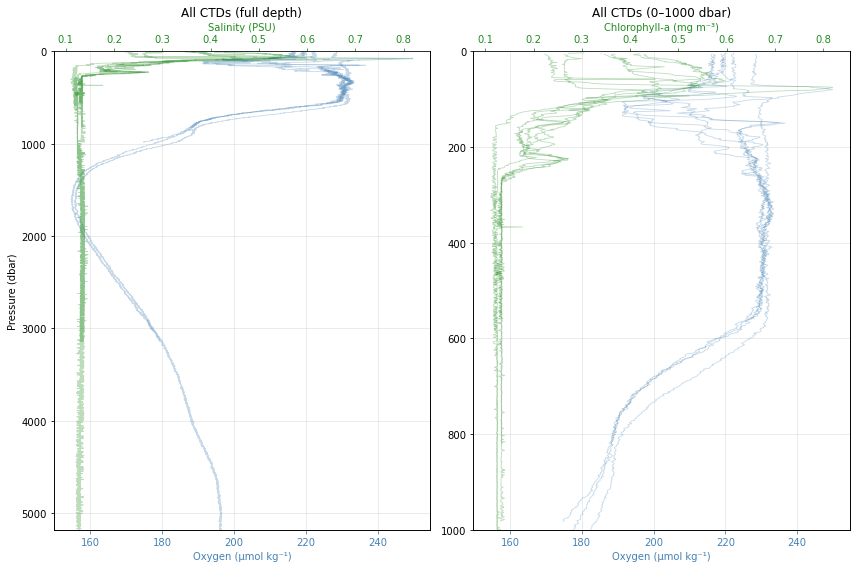

In [58]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 8),
    sharey=False
)

pressure = ds.pressure

# Panel axes
axO_full = axes[0]
axS_full = axO_full.twiny()

axO_shallow = axes[1]
axS_shallow = axO_shallow.twiny()

# Loop over all CTDs
for t in range(ds.sizes["time"]):
    for la in range(ds.sizes["latitude"]):
        for lo in range(ds.sizes["longitude"]):

            O2 = ds.oxygen.isel(time=t, latitude=la, longitude=lo)
            F = ds.fluorometer.isel(time=t, latitude=la, longitude=lo)

            # --- Full depth ---
            axO_full.plot(O2, pressure, color="steelblue", lw=0.8, alpha=0.3)
            axS_full.plot(F,  pressure, color="forestgreen",  lw=0.8, alpha=0.3)

            # --- 0–1000 dbar ---
            axO_shallow.plot(O2, pressure, color="steelblue", lw=0.8, alpha=0.3)
            axS_shallow.plot(F,  pressure, color="forestgreen",  lw=0.8, alpha=0.3)

# Invert pressure axis
for ax in [axO_full, axO_shallow]:
    ax.invert_yaxis()

# Y-limits
axO_full.set_ylim(pressure.max(), 0)
axO_shallow.set_ylim(1000, 0)

# Labels
axO_full.set_xlabel("Oxygen (µmol kg⁻¹)", color="steelblue")
axS_full.set_xlabel("Salinity (PSU)", color="forestgreen")

axO_shallow.set_xlabel("Oxygen (µmol kg⁻¹)", color="steelblue")
axS_shallow.set_xlabel("Chlorophyll‑a (mg m⁻³)", color="forestgreen")

axO_full.set_ylabel("Pressure (dbar)")

# Tick colours
axO_full.tick_params(axis="x", colors="steelblue")
axS_full.tick_params(axis="x", colors="forestgreen")
axO_shallow.tick_params(axis="x", colors="steelblue")
axS_shallow.tick_params(axis="x", colors="forestgreen")

# Titles
axO_full.set_title("All CTDs (full depth)")
axO_shallow.set_title("All CTDs (0–1000 dbar)")

# Grid and cosmetics
for ax in [axO_full, axO_shallow]:
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()


### Bonney Transect

In [134]:
os.chdir(r'C:\Users\nribeiro\OneDrive - University of Tasmania\IMOS Shared Docs\CAPSTAN 2025\Datasets\CTD Bonney') #Will need to change this 

In [135]:
ds = xr.open_mfdataset(
    "in2026_*.nc",
    combine="by_coords"
)

In [136]:
ds

<xarray.Dataset>
Dimensions:              (time: 4, latitude: 4, pressure: 2678, longitude: 4)
Coordinates:
  * time                 (time) datetime64[ns] 2026-05-01T18:48:11.794996736 ...
  * latitude             (latitude) float64 -38.87 -38.64 -38.62 -38.58
  * pressure             (pressure) float64 3.461 4.0 ... 2.674e+03 2.675e+03
  * longitude            (longitude) float64 141.0 141.1 141.1 141.2
Data variables: (12/30)
    woce_date            (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    woce_time            (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    temperature          (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    temperatureFlag      (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    conductivity         (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    conductivityFlag     (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    ...                   ...
    transmissometer      (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    transmissometerFlag  (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    fluorometer          (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    fluorometerFlag      (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    obs                  (longitude, latitude, pressure, time) float64 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
    obsFlag              (longitude, latitude, pressure, time) float32 dask.array<chunksize=(1, 4, 2678, 4), meta=np.ndarray>
Attributes: (12/14)
    WOCE_Version:    3.0
    Conventions:     COARDS/WOCE/CF-1.5
    History:         Created on 02-May-2026 06:08:33
    Organisation:    CSIRO Marine Research
    Survey:          IN2026_T02
    Vessel:          RV Investigator
    ...              ...
    StartTime:       01-May-2026 18:48:11
    BottomTime:      01-May-2026 19:36:46
    EndTime:         01-May-2026 20:52:50
    WaterDepth:      2694.74
    MinAltitude:     Unknown
    PressureBin:     1

In [138]:
## Calculate density

In [139]:
# Extract coordinate arrays
lon0 = ds.longitude.values
lat0 = ds.latitude.values

# Broadcast to full 4D shape of temperature
lon = np.broadcast_to(lon0, ds.temperature.shape)
lat = np.broadcast_to(lat0, ds.temperature.shape)


In [140]:
T  = ds.temperature.values.flatten()
S  = ds.salinity.values.flatten()
O2 = ds.oxygen.values.flatten()

P = np.tile(
    ds.pressure.values,
    int(T.size / ds.pressure.size)
)

lon = lon.flatten()
lat = lat.flatten()

In [141]:
mask = np.isfinite(T) & np.isfinite(S) & np.isfinite(O2) & np.isfinite(P)

T  = T[mask]
S  = S[mask]
O2 = O2[mask]
P  = P[mask]
lon = lon[mask]
lat = lat[mask]


In [142]:
SA = gsw.SA_from_SP(S, P, lon, lat)

In [143]:
CT = gsw.CT_from_t(SA, T, P)

In [144]:
sigma0 = gsw.sigma0(SA, CT)

In [145]:
## Transect Plot

In [146]:
ds_sec = ds.mean(dim=["longitude", "time"])

In [147]:
ds_sec

<xarray.Dataset>
Dimensions:              (latitude: 4, pressure: 2678)
Coordinates:
  * latitude             (latitude) float64 -38.87 -38.64 -38.62 -38.58
  * pressure             (pressure) float64 3.461 4.0 ... 2.674e+03 2.675e+03
Data variables: (12/30)
    woce_date            (latitude, pressure) float64 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    woce_time            (latitude, pressure) float64 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    temperature          (latitude, pressure) float64 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    temperatureFlag      (latitude, pressure) float32 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    conductivity         (latitude, pressure) float64 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    conductivityFlag     (latitude, pressure) float32 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    ...                   ...
    transmissometer      (latitude, pressure) float64 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    transmissometerFlag  (latitude, pressure) float32 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    fluorometer          (latitude, pressure) float64 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    fluorometerFlag      (latitude, pressure) float32 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    obs                  (latitude, pressure) float64 dask.array<chunksize=(4, 2678), meta=np.ndarray>
    obsFlag              (latitude, pressure) float32 dask.array<chunksize=(4, 2678), meta=np.ndarray>

In [148]:
Tsec = ds_sec.temperature.compute()
P = ds_sec.pressure
lat = ds_sec.latitude

Ssec = ds_sec.salinity.compute()

In [149]:
Osec = ds_sec.oxygen.compute()

In [150]:
## masking depths

In [151]:
# Tsec dims: (pressure, latitude)
max_p = Tsec.notnull().where(Tsec.notnull()).idxmax(dim="pressure")



In [152]:
Tsec_masked = Tsec.where(Tsec.pressure <= max_p)

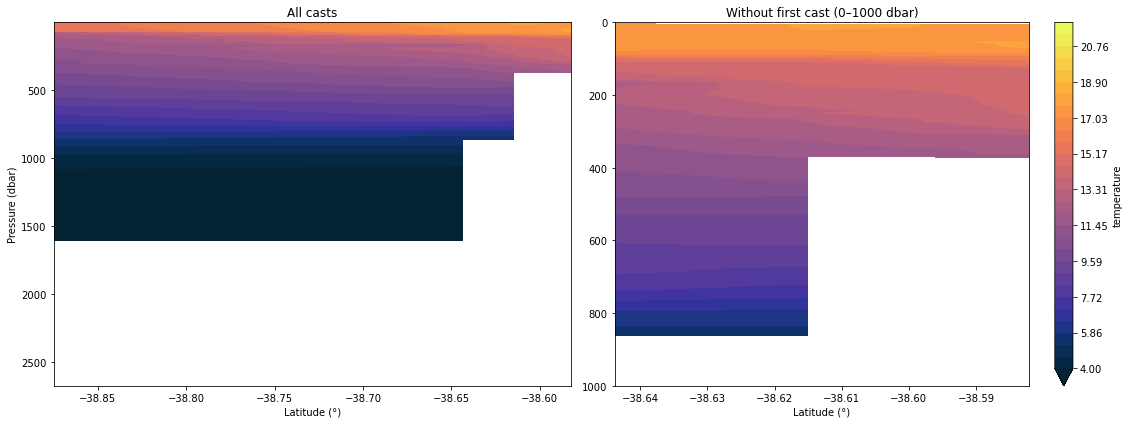

In [153]:
vmin = 4
vmax = 22


fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharey=False   # important: do NOT share y-axis
)

# --- Panel 1: All casts ---
Tsec.plot.contourf(
    ax=axes[0],
    x="latitude",
    y="pressure",
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap=cmocean.cm.thermal,
    add_colorbar=False
)

axes[0].invert_yaxis()
axes[0].set_title("All casts")
axes[0].set_xlabel("Latitude (°)")
axes[0].set_ylabel("Pressure (dbar)")

# --- Panel 2: Without first cast, 0–1000 dbar ---
Tsec.isel(latitude=slice(1, None)).plot.contourf(
    ax=axes[1],
    x="latitude",
    y="pressure",
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap=cmocean.cm.thermal,
    add_colorbar=True
)

axes[1].invert_yaxis()
axes[1].set_ylim(1000, 0)   # <-- key line
axes[1].set_title("Without first cast (0–1000 dbar)")
axes[1].set_xlabel("Latitude (°)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


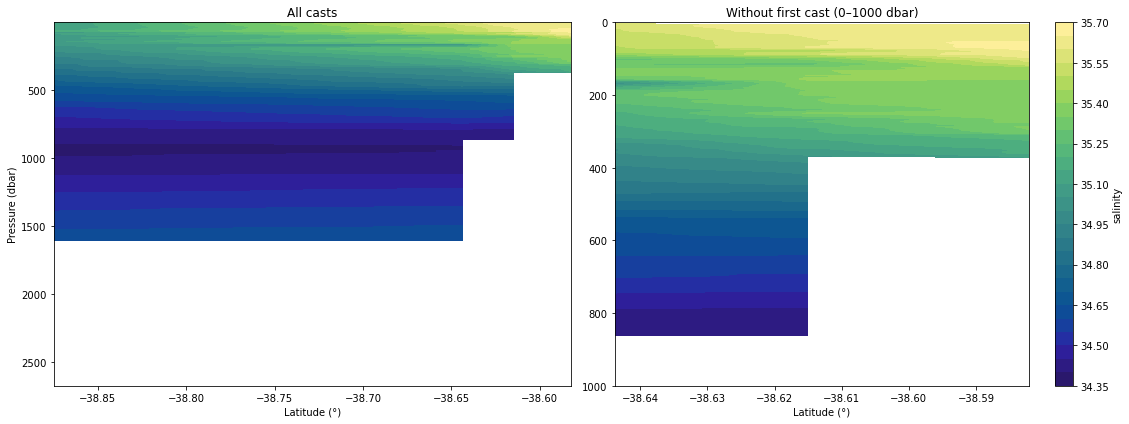

In [154]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharey=False   # important: do NOT share y-axis
)

# --- Panel 1: All casts ---
Ssec.plot.contourf(
    ax=axes[0],
    x="latitude",
    y="pressure",
    levels=30,
    cmap=cmocean.cm.haline,
    add_colorbar=False
)

axes[0].invert_yaxis()
axes[0].set_title("All casts")
axes[0].set_xlabel("Latitude (°)")
axes[0].set_ylabel("Pressure (dbar)")

# --- Panel 2: Without first cast, 0–1000 dbar ---
Ssec.isel(latitude=slice(1, None)).plot.contourf(
    ax=axes[1],
    x="latitude",
    y="pressure",
    levels=30,
    cmap=cmocean.cm.haline,
    add_colorbar=True
)

axes[1].invert_yaxis()
axes[1].set_ylim(1000, 0)   # <-- key line
axes[1].set_title("Without first cast (0–1000 dbar)")
axes[1].set_xlabel("Latitude (°)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()



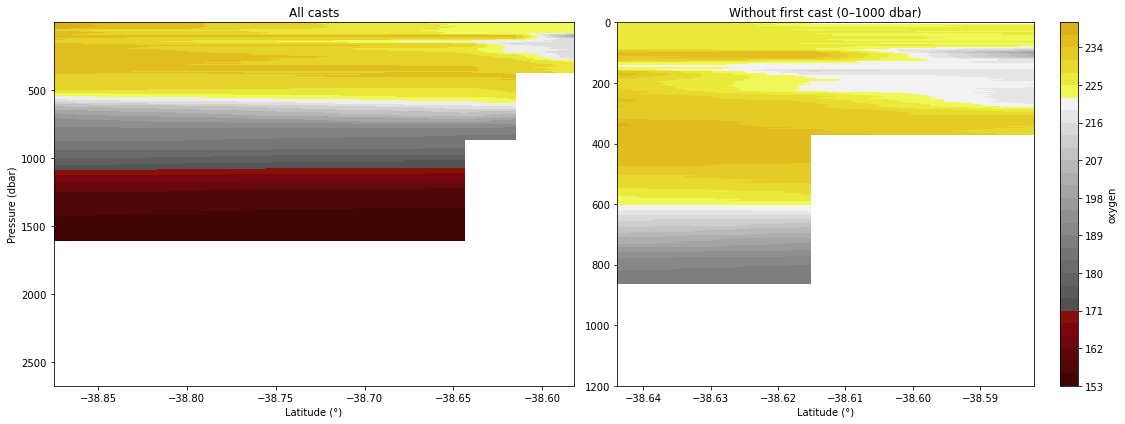

In [159]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharey=False   # important: do NOT share y-axis
)

# --- Panel 1: All casts ---
Osec.plot.contourf(
    ax=axes[0],
    x="latitude",
    y="pressure",
    levels=30,
    cmap=cmocean.cm.oxy,
    add_colorbar=False
)

axes[0].invert_yaxis()
axes[0].set_title("All casts")
axes[0].set_xlabel("Latitude (°)")
axes[0].set_ylabel("Pressure (dbar)")

# --- Panel 2: Without first cast, 0–1000 dbar ---
Osec.isel(latitude=slice(1, None)).plot.contourf(
    ax=axes[1],
    x="latitude",
    y="pressure",
    levels=30,
    cmap=cmocean.cm.oxy,
    add_colorbar=True
)

axes[1].invert_yaxis()
axes[1].set_ylim(1200, 0)   # <-- key line
axes[1].set_title("Without first cast (0–1000 dbar)")
axes[1].set_xlabel("Latitude (°)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()



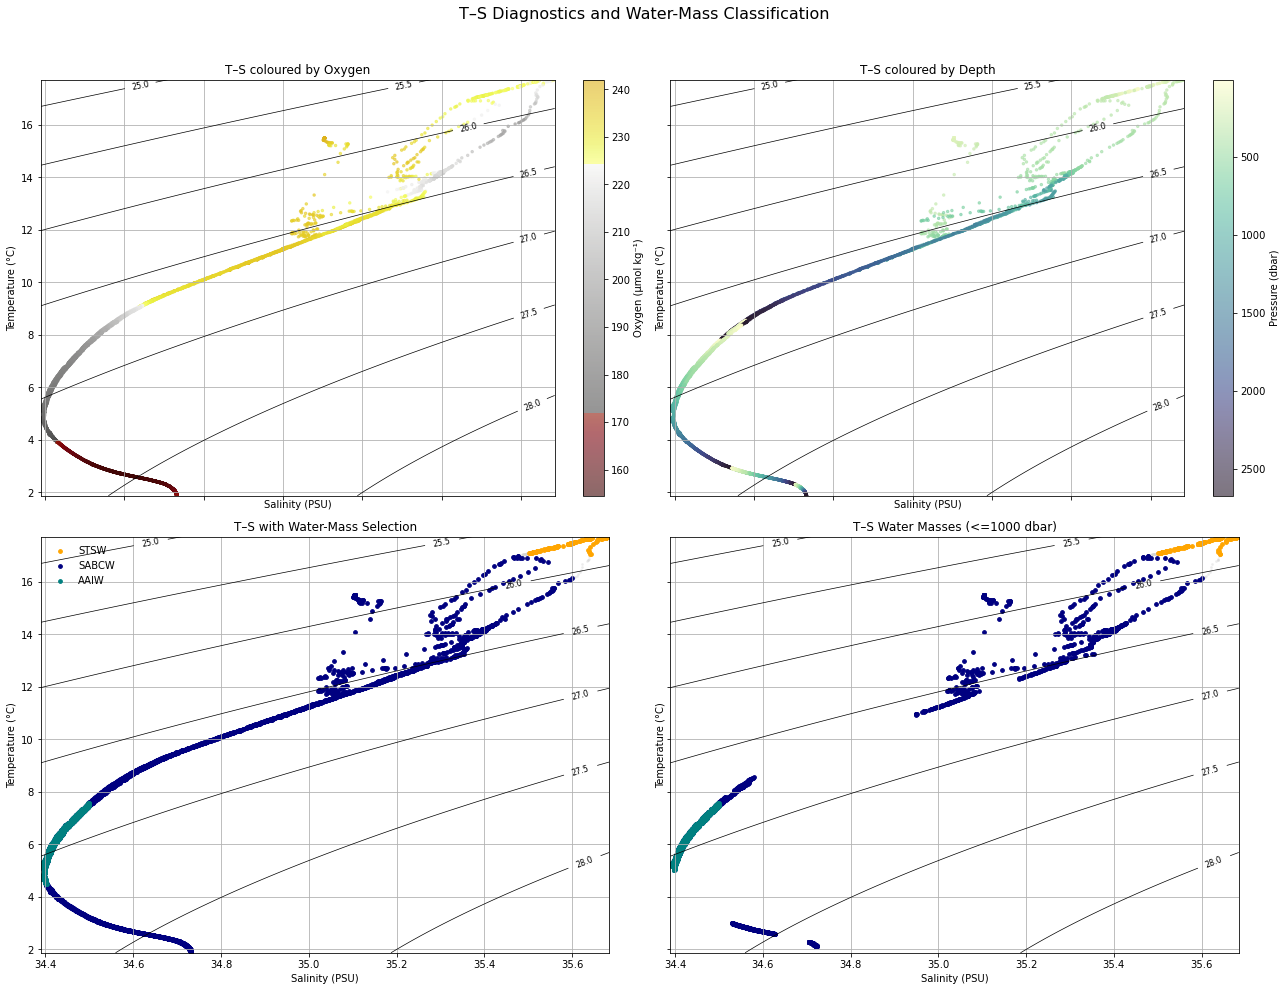

In [155]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean
import gsw

# --------------------------------------------------
# Variables
# --------------------------------------------------
temp_var = "temperature"
sal_var  = "salinity"
oxy_var  = "oxygen"

pressure = ds.pressure.values

# --------------------------------------------------
# Build ONE global flattened dataset (CRITICAL FIX)
# --------------------------------------------------
T = ds[temp_var].values.flatten()
S = ds[sal_var].values.flatten()
O2 = ds[oxy_var].values.flatten()

P = np.tile(
    pressure,
    int(T.size / pressure.size)
)

mask = np.isfinite(T) & np.isfinite(S) & np.isfinite(O2) & np.isfinite(P)

T  = T[mask]
S  = S[mask]
O2 = O2[mask]
P  = P[mask]

# --------------------------------------------------
# Water-mass indices (NOW CORRECT)
# --------------------------------------------------
idx_STSW  = (T > 17) & (S > 35.5)
idx_SABCW = (T < 17) & (S < 35.6)
idx_NWIIW = (O2 < 110) & (P > 600)
idx_AAIW  = (S < 34.5) & (S > 34.1) & (T > 2) & (T < 8) & (O2 > 180)
idx_NADW = (S > 34.9) & (T > 2) & (T < 4)

deep = P <= 1000

# --------------------------------------------------
# Create 2×2 figure
# --------------------------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 14),
    sharex=True,
    sharey=True
)

ax_oxy, ax_depth = axes[0]
ax_wm, ax_wm_deep = axes[1]

# --------------------------------------------------
# Panel 1: T–S coloured by oxygen
# --------------------------------------------------
sc_oxy = ax_oxy.scatter(
    S, T, c=O2,
    cmap=cmocean.cm.oxy,
    s=6, alpha=0.6
)

# --------------------------------------------------
# Panel 2: T–S coloured by depth
# --------------------------------------------------
sc_dep = ax_depth.scatter(
    S, T, c=P,
    cmap=cmocean.cm.deep,
    s=6, alpha=0.6
)

# --------------------------------------------------
# Panel 3: Water-mass classification (ALL data)
# --------------------------------------------------
ax_wm.scatter(S, T, s=3, color="lightgrey", alpha=0.3)

ax_wm.scatter(S[idx_STSW],  T[idx_STSW],  color="orange",     s=14, label="STSW")
ax_wm.scatter(S[idx_SABCW], T[idx_SABCW], color="navy",       s=14, label="SABCW")
#ax_wm.scatter(S[idx_NWIIW], T[idx_NWIIW], color="red",  s=14, label="NWIIW")
ax_wm.scatter(S[idx_AAIW],  T[idx_AAIW],  color="teal",       s=14, label="AAIW")
#ax_wm.scatter(S[idx_NADW],  T[idx_NADW],  color="red",       s=14, label="NADW")

# --------------------------------------------------
# Panel 4: Deep water only (<=1000 dbar)
# --------------------------------------------------
ax_wm_deep.scatter(
    S[deep], T[deep],
    s=3, color="lightgrey", alpha=0.3
)

ax_wm_deep.scatter(
    S[idx_SABCW & deep], T[idx_SABCW & deep],
    color="navy", s=14
)
ax_wm_deep.scatter(
    S[idx_STSW & deep], T[idx_STSW & deep],
    color="orange", s=14
)

ax_wm_deep.scatter(
    S[idx_AAIW & deep], T[idx_AAIW & deep],
    color="teal", s=14
)



# --------------------------------------------------
# Isopycnals (σ₀)
# --------------------------------------------------
Sg, Tg = np.meshgrid(
    np.linspace(S.min(), S.max(), 120),
    np.linspace(T.min(), T.max(), 120)
)

sigma0 = gsw.sigma0(Sg, Tg)

for ax in [ax_oxy, ax_depth, ax_wm, ax_wm_deep]:
    cs = ax.contour(Sg, Tg, sigma0, colors="k", linewidths=0.7)
    ax.clabel(cs, fmt="%.1f", fontsize=8)
    ax.grid(True)

# --------------------------------------------------
# Labels & titles
# --------------------------------------------------
ax_oxy.set_title("T–S coloured by Oxygen")
ax_depth.set_title("T–S coloured by Depth")
ax_wm.set_title("T–S with Water-Mass Selection")
ax_wm_deep.set_title("T–S Water Masses (<=1000 dbar)")

for ax in axes.ravel():
    ax.set_xlabel("Salinity (PSU)")
    ax.set_ylabel("Temperature (°C)")

# --------------------------------------------------
# Colourbars
# --------------------------------------------------
cbar_oxy = fig.colorbar(sc_oxy, ax=ax_oxy, fraction=0.046)
cbar_oxy.set_label("Oxygen (µmol kg⁻¹)")

cbar_dep = fig.colorbar(sc_dep, ax=ax_depth, fraction=0.046)
cbar_dep.set_label("Pressure (dbar)")
cbar_dep.ax.invert_yaxis()

ax_wm.legend(frameon=False)

fig.suptitle("T–S Diagnostics and Water-Mass Classification", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

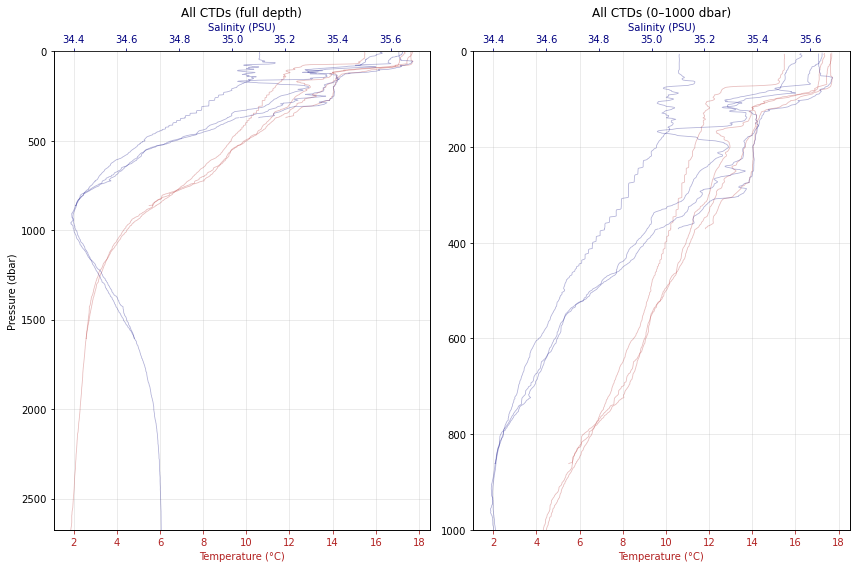

In [156]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 8),
    sharey=False
)

pressure = ds.pressure

# Create twin x-axes
axT_full = axes[0]
axS_full = axT_full.twiny()

axT_shallow = axes[1]
axS_shallow = axT_shallow.twiny()

# Loop over all CTDs
for t in range(ds.sizes["time"]):
    for la in range(ds.sizes["latitude"]):
        for lo in range(ds.sizes["longitude"]):

            T = ds.temperature.isel(
                time=t, latitude=la, longitude=lo
            )
            S = ds.salinity.isel(
                time=t, latitude=la, longitude=lo
            )

            # --- Full depth panel ---
            axT_full.plot(
                T, pressure,
                color="firebrick", lw=0.8, alpha=0.3
            )
            axS_full.plot(
                S, pressure,
                color="navy", lw=0.8, alpha=0.3
            )

            # --- 0–1000 dbar panel ---
            axT_shallow.plot(
                T, pressure,
                color="firebrick", lw=0.8, alpha=0.3
            )
            axS_shallow.plot(
                S, pressure,
                color="navy", lw=0.8, alpha=0.3
            )

# Invert pressure axis
for ax in [axT_full, axT_shallow]:
    ax.invert_yaxis()

# Set y-limits
axT_full.set_ylim(pressure.max(), 0)
axT_shallow.set_ylim(1000, 0)

# Labels
axT_full.set_xlabel("Temperature (°C)", color="firebrick")
axS_full.set_xlabel("Salinity (PSU)", color="navy")
axT_shallow.set_xlabel("Temperature (°C)", color="firebrick")
axS_shallow.set_xlabel("Salinity (PSU)", color="navy")

axT_full.set_ylabel("Pressure (dbar)")

# Titles
axT_full.set_title("All CTDs (full depth)")
axT_shallow.set_title("All CTDs (0–1000 dbar)")

# Tick colours for clarity
axT_full.tick_params(axis="x", colors="firebrick")
axS_full.tick_params(axis="x", colors="navy")
axT_shallow.tick_params(axis="x", colors="firebrick")
axS_shallow.tick_params(axis="x", colors="navy")

# Grid and cosmetics
for ax in [axT_full, axT_shallow]:
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()


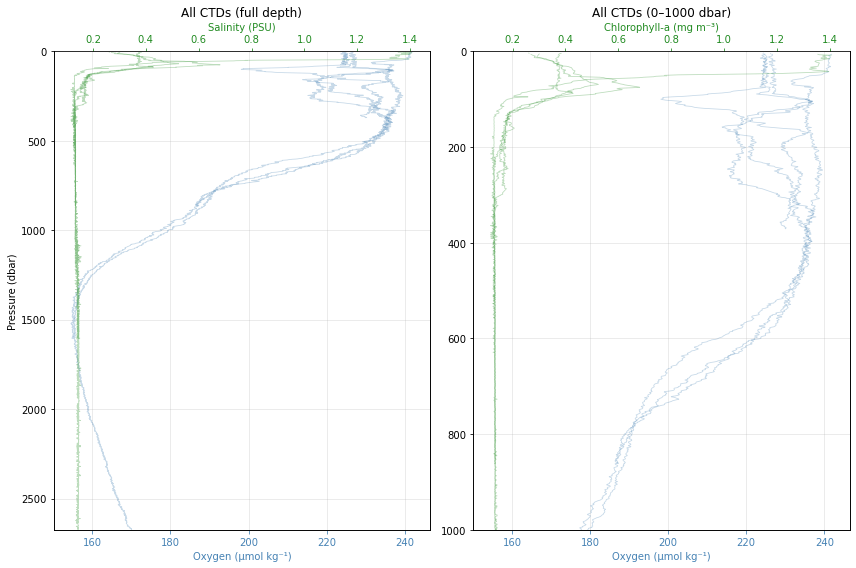

In [157]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 8),
    sharey=False
)

pressure = ds.pressure

# Panel axes
axO_full = axes[0]
axS_full = axO_full.twiny()

axO_shallow = axes[1]
axS_shallow = axO_shallow.twiny()

# Loop over all CTDs
for t in range(ds.sizes["time"]):
    for la in range(ds.sizes["latitude"]):
        for lo in range(ds.sizes["longitude"]):

            O2 = ds.oxygen.isel(time=t, latitude=la, longitude=lo)
            F = ds.fluorometer.isel(time=t, latitude=la, longitude=lo)

            # --- Full depth ---
            axO_full.plot(O2, pressure, color="steelblue", lw=0.8, alpha=0.3)
            axS_full.plot(F,  pressure, color="forestgreen",  lw=0.8, alpha=0.3)

            # --- 0–1000 dbar ---
            axO_shallow.plot(O2, pressure, color="steelblue", lw=0.8, alpha=0.3)
            axS_shallow.plot(F,  pressure, color="forestgreen",  lw=0.8, alpha=0.3)

# Invert pressure axis
for ax in [axO_full, axO_shallow]:
    ax.invert_yaxis()

# Y-limits
axO_full.set_ylim(pressure.max(), 0)
axO_shallow.set_ylim(1000, 0)

# Labels
axO_full.set_xlabel("Oxygen (µmol kg⁻¹)", color="steelblue")
axS_full.set_xlabel("Salinity (PSU)", color="forestgreen")

axO_shallow.set_xlabel("Oxygen (µmol kg⁻¹)", color="steelblue")
axS_shallow.set_xlabel("Chlorophyll‑a (mg m⁻³)", color="forestgreen")

axO_full.set_ylabel("Pressure (dbar)")

# Tick colours
axO_full.tick_params(axis="x", colors="steelblue")
axS_full.tick_params(axis="x", colors="forestgreen")
axO_shallow.tick_params(axis="x", colors="steelblue")
axS_shallow.tick_params(axis="x", colors="forestgreen")

# Titles
axO_full.set_title("All CTDs (full depth)")
axO_shallow.set_title("All CTDs (0–1000 dbar)")

# Grid and cosmetics
for ax in [axO_full, axO_shallow]:
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()
